In [1]:
from __future__ import annotations
from collections.abc import Sequence
from collections import defaultdict
import numpy as np
import rustworkx
import matplotlib.pyplot as plt

from qiskit.circuit import QuantumCircuit, Parameter
from qiskit.circuit.library import CXGate, CZGate, ECRGate
from qiskit.providers import Backend
from qiskit.visualization import plot_error_map
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import PubResult

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator

In [2]:
from qiskit_ibm_runtime import QiskitRuntimeService, Estimator

service = QiskitRuntimeService(name="TJ")
service.active_account()
print('Available backends:')
print(service.backends(simulator=False))



qiskit_runtime_service.__init__:WARNING:2026-05-08 06:15:29,412: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-08 06:15:29,419: Loading instance: open-instance, plan: open


Available backends:
[<IBMBackend('ibm_fez')>, <IBMBackend('ibm_marrakesh')>, <IBMBackend('ibm_kingston')>]


In [3]:
backend = service.backend("ibm_fez")
print(f"Backend = {backend.name}")

qiskit_runtime_service.backends:WARNING:2026-05-08 06:15:31,138: Using instance: open-instance, plan: open


Backend = ibm_fez


In [5]:
# Experiment options
num_params = 3
num_randomizations = 700
num_randomizations_learning = 40
max_batch_circuits = 3 * num_params
shots_per_randomization = 64
learning_pair_depths = [0, 1, 2, 4, 6, 12, 24]
noise_factors = [1, 1.3, 1.6]
extrapolated_noise_factors = np.linspace(0, max(noise_factors), 20)

# Base option formatting
options = {
    # Builtin resilience settings for ZNE
    "resilience": {
        "measure_mitigation": True,
        "zne_mitigation": True,
        # TREX noise learning configuration
        "measure_noise_learning": {
            "num_randomizations": num_randomizations_learning,
            "shots_per_randomization": 1024,
        },
        # PEA noise model configuration
        "layer_noise_learning": {
            "max_layers_to_learn": 3,
            "layer_pair_depths": learning_pair_depths,
            "shots_per_randomization": shots_per_randomization,
            "num_randomizations": num_randomizations_learning,
        },
        "zne": {
            "amplifier": "pea",
            "noise_factors": noise_factors,
            "extrapolator": ("exponential", "linear"),
            "extrapolated_noise_factors": extrapolated_noise_factors.tolist(),
        },
    },
    # Randomization configuration
    "twirling": {
        "num_randomizations": num_randomizations,
        "shots_per_randomization": shots_per_randomization,
        "strategy": "active-circuit",
    },
    # Optional Dynamical Decoupling (DD)
    "dynamical_decoupling": {"enable": True, "sequence_type": "XY4"},
}

In [6]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit.primitives import BackendEstimatorV2


# 1. Extract the noise model and coupling map from the real hardware
noise_model = NoiseModel.from_backend(backend)

# 2. Build a local simulator using that specific noise profile
noisy_sim = AerSimulator.from_backend(backend, noise_model=noise_model)

# 3. Wrap it in the V2 interface
estimator = BackendEstimatorV2(backend=noisy_sim)

# Now pass `noisy_estimator` to your VQE algorithm

In [7]:
import numpy as np
import pandas as pd

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit



from qiskit_nature.second_q.mappers import JordanWignerMapper
mapper = JordanWignerMapper()

from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD

num_spatial_orbitals = 2
num_particles = (1, 1)
ansatz = UCCSD(
    num_spatial_orbitals,
    num_particles,
    mapper,
    initial_state=HartreeFock(
        num_spatial_orbitals,
        num_particles,
        mapper,
    ),
)
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP, COBYLA

from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from scipy.optimize import minimize

from qiskit.transpiler import PassManager
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
ansatz_isa = pm.run(ansatz)

from time import time


energies = []
ground_energies = []
optimizer_times = []
iteration_number = []
optimizer_results = []
nuclear_repulsion_energies = []
energy_histories = []
optimal_parameters_list = []


# Bond lengths in Angstrom
bond_lengths = np.arange(0.30, 1.50, 0.05) 


for r in bond_lengths:
    # Define H2 geometry
    geometry = f"H 0 0 0; H 0 0 {r}"

    # PySCF driver
    driver = PySCFDriver(
        atom=geometry,
        basis="sto3g",
        spin=0,
        charge=0,
        unit=DistanceUnit.ANGSTROM,
    )

    # Run electronic structure calculation
    problem = driver.run()
    nuclear_repulsion = problem.hamiltonian.nuclear_repulsion_energy


    #print(f"Running VQE for bond length {r} Å with initial parameters: {initial_parameters[r]}")
    vqe_solver = VQE(estimator, ansatz, COBYLA())
    vqe_solver.initial_point = [0.0821556, 0.03705277, -0.11171107]      # IMPORTANT
    x0 = vqe_solver.initial_point

    solver = GroundStateEigensolver(mapper, vqe_solver)

    main_operator, aux_ops = solver.get_qubit_operators(problem)

    H = main_operator
    hamiltonian_isa = H.apply_layout(ansatz_isa.layout)

    energy_history = []

    def cost_func(params, ansatz, H, estimator):
        pub = (ansatz, [H], [params])
        result = estimator.run(pubs=[pub]).result()
        energy = result[0].data.evs[0]
        energy_history.append(energy)  
        return energy

    start_time = time()
    result = minimize(
        cost_func,
        x0,
        args=(ansatz_isa, hamiltonian_isa, estimator),
        method="cobyla",
        options={"maxiter": 15, "disp": True},)

    optimizer_time = time() - start_time
    energy = result.fun
    optimal_parameters = result.x
    ground_state_energy = energy + nuclear_repulsion
    print(f"Ground state energy for bond length {r} Å: {ground_state_energy:.6f} Hartree")


    energies.append(energy)
    ground_energies.append(ground_state_energy)
    optimizer_results.append(result)
    optimizer_times.append(optimizer_time)
    nuclear_repulsion_energies.append(nuclear_repulsion)
    iteration_number.append(result.nfev)
    energy_histories.append(energy_history)
    optimal_parameters_list.append(optimal_parameters)





Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 15   Least value of F = -2.130189277000513
The corresponding X is:
[ 0.06725381  0.03440778 -0.06405668]

Ground state energy for bond length 0.3 Å: -0.366265 Hartree
Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 15   Least value of F = -2.066696111049763
The corresponding X is:
[ 0.0821556   0.03705277 -0.11171107]

Ground state energy for bond length 0.35 Å: -0.554761 Hartree
Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 15   Least value of F = -2.0281533064073556
The corresponding X is:
[ 0.11559413 -0.00012067 -0.11171107]

Ground state energy for bond length 0.39999999999999997 Å: -0.705210 Hartree
Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 15   Least value of F = -1.9834248764

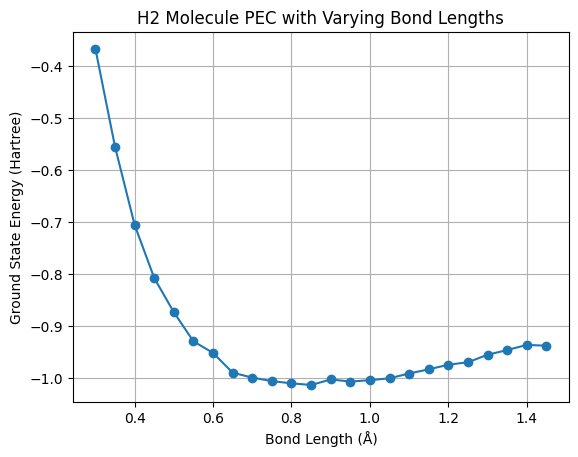

In [10]:
from matplotlib import pyplot as plt

plt.plot(bond_lengths, ground_energies, marker='o')
plt.grid(True)
plt.xlabel("Bond Length (Å)")
plt.ylabel("Ground State Energy (Hartree)")
plt.title("H2 Molecule PEC with Varying Bond Lengths")
plt.show()

In [8]:

# Create table
df = pd.DataFrame({
    "Bond Length": bond_lengths,
    "Results": optimizer_results,
    "Ground State Energy (Hartree)": ground_energies,
    "Time (s)": optimizer_times,
    "Nuclear Repulsion Energy (Hartree)": nuclear_repulsion_energies,
    "Electronic Energies (Hartree)": energies,
    "Convergence History": energy_histories,
    "optimal_parameters_list": optimal_parameters_list
})
print(df)

    Bond Length                                            Results  \
0          0.30  {'x': [0.06725381185026749, 0.0344077805033914...   
1          0.35  {'x': [0.0821556, 0.03705277, -0.11171107], 's...   
2          0.40  {'x': [0.11559413181984216, -0.000120669304608...   
3          0.45  {'x': [0.05841711423693975, 0.0673621338713134...   
4          0.50  {'x': [-0.08360061867825011, 0.032991105103864...   
5          0.55  {'x': [-0.1001472101929903, 0.0305007268131326...   
6          0.60  {'x': [0.0244460281316425, -0.0357937447688134...   
7          0.65  {'x': [-0.049498363821820525, 0.04827819078315...   
8          0.70  {'x': [0.12257594642425748, -0.002620551147390...   
9          0.75  {'x': [0.0821556, 0.03705277, -0.11171107], 's...   
10         0.80  {'x': [0.07300221192485104, 0.0286826749826077...   
11         0.85  {'x': [0.11639293002191556, 0.0006137080887701...   
12         0.90  {'x': [0.0977373108064401, 0.04493024212873722...   
13         0.95  {'x

In [9]:
df.to_pickle("dataframe_noise_simulation.pkl")